<a href="https://colab.research.google.com/github/Drei-i/MachineLearningPIT/blob/main/AlgorithmComparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Rabaya(Burnout_DATASET) - Sheet1.csv to Rabaya(Burnout_DATASET) - Sheet1.csv

===== MODEL COMPARISON =====

                 Model    Metric     Score
0    Linear Regression  R² Score  0.936151
1  Logistic Regression  Accuracy  0.933333
2        Decision Tree  Accuracy  0.877778
3        Random Forest  Accuracy  0.925000


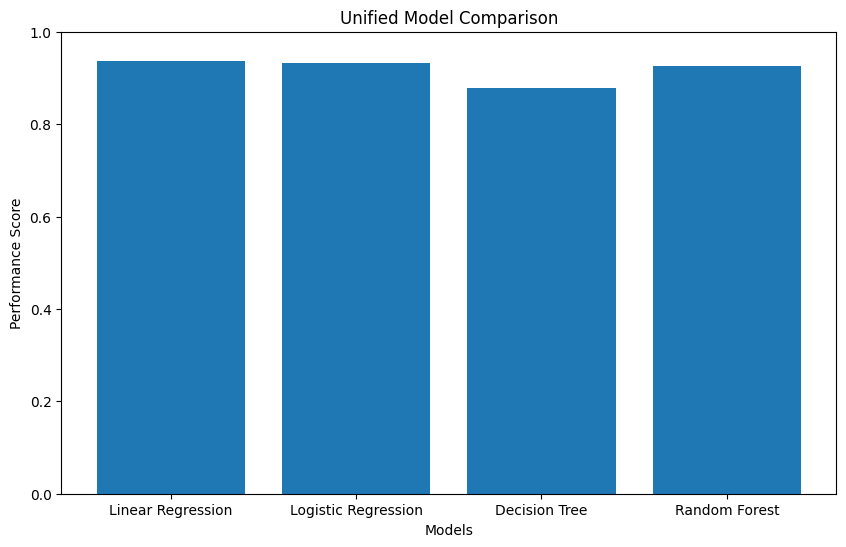

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, r2_score

# =====================================
# MANUAL DATASET UPLOAD
# =====================================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

# =====================================
# FEATURE SELECTION
# =====================================

features = [
    'work_hours',
    'screen_time_hours',
    'meetings_count',
    'breaks_taken',
    'after_hours_work',
    'sleep_hours',
    'task_completion_rate'
]

# =====================================
# LINEAR REGRESSION (R² SCORE)
# =====================================

X_reg = df[features].values

y_reg = df['burnout_score'].values

# Standardize Features
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Train-Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Add Bias Column
X_train_reg = np.c_[np.ones(X_train_reg.shape[0]), X_train_reg]
X_test_reg = np.c_[np.ones(X_test_reg.shape[0]), X_test_reg]

# Initialize Parameters
m, n = X_train_reg.shape
theta = np.zeros(n)

learning_rate = 0.01
epochs = 1000

# Cost Function
cost_history = []

for epoch in range(epochs):

    predictions = X_train_reg.dot(theta)

    error = predictions - y_train_reg

    gradients = (1 / m) * X_train_reg.T.dot(error)

    theta = theta - learning_rate * gradients

    cost = (1 / (2 * m)) * np.sum(error ** 2)

    cost_history.append(cost)

# Linear Regression Predictions
y_pred_reg = X_test_reg.dot(theta)

# Linear Regression Evaluation
linear_r2 = r2_score(y_test_reg, y_pred_reg)

# =====================================
# CLASSIFICATION PREPARATION
# =====================================

# Convert burnout_score into binary classes
median_score = df['burnout_score'].median()

# 1 = High Burnout
# 0 = Low Burnout

df['burnout_class'] = (
    df['burnout_score'] >= median_score
).astype(int)

X_cls = df[features]
y_cls = df['burnout_class']

# Train-Test Split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

# =====================================
# LOGISTIC REGRESSION
# =====================================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_cls, y_train_cls)

log_pred = log_model.predict(X_test_cls)

log_accuracy = accuracy_score(y_test_cls, log_pred)

# =====================================
# DECISION TREE
# =====================================

DT_model = DecisionTreeClassifier(random_state=42)

DT_model.fit(X_train_cls, y_train_cls)

DT_pred = DT_model.predict(X_test_cls)

DT_accuracy = accuracy_score(y_test_cls, DT_pred)

# =====================================
# RANDOM FOREST
# =====================================

RF_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

RF_model.fit(X_train_cls, y_train_cls)

RF_pred = RF_model.predict(X_test_cls)

RF_accuracy = accuracy_score(y_test_cls, RF_pred)

# =====================================
# COMPARISON TABLE
# =====================================

comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Metric': [
        'R² Score',
        'Accuracy',
        'Accuracy',
        'Accuracy'
    ],
    'Score': [
        linear_r2,
        log_accuracy,
        DT_accuracy,
        RF_accuracy
    ]
})

print('\n===== MODEL COMPARISON =====\n')
print(comparison_df)

# =====================================
# BAR GRAPH COMPARISON
# =====================================

plt.figure(figsize=(10,6))

plt.bar(
    comparison_df['Model'],
    comparison_df['Score']
)

plt.title('Unified Model Comparison')
plt.xlabel('Models')
plt.ylabel('Performance Score')
plt.ylim(0, 1)

plt.show()